# ETF (FTSE 100 ETF) Daily Return Prediction — Multi-Model Comparison

> **Target**: Daily Return (%) of FTSE 100 ETF  
> **Period**: 2014-01-02 ~ 2025-12-31  
> **Text Representations**: TF-IDF, FinBERT  
> **Financial Features**: Gold, Oil, Bond, CAD, CNY, EUR, JPY, MXN, VIX, Bitcoin (daily returns)  
> **Models**: 15+ models including Baselines, Tree-based, LSTM, Transformer, Ensemble

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, re, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility seeds
SEED = 42
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

import torch
torch.manual_seed(SEED)

# NLTK setup
import nltk
local_nltk_dir = os.path.join(os.getcwd(), 'nltk_data')
nltk.data.path.insert(0, local_nltk_dir)
for pkg in ['stopwords', 'wordnet']:
    try:
        nltk.data.find('corpora/' + pkg)
    except LookupError:
        nltk.download(pkg, download_dir=local_nltk_dir, quiet=True)

from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, r2_score)
import lightgbm as lgb

# Deep Learning
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import (LSTM, Dense, Bidirectional, PReLU, Dropout,
                          Input, LayerNormalization, GlobalAveragePooling1D)
from keras.layers import MultiHeadAttention
from keras.callbacks import EarlyStopping

# FinBERT
from transformers import BertTokenizer, BertModel

# Plot settings
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print("All imports successful.")

All imports successful.


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# TF-IDF
TFIDF_MAX_FEATURES = 500
TFIDF_MIN_DF = 2
TFIDF_MAX_DF = 0.8

# FinBERT
FINBERT_PCA_DIM = 50
FINBERT_BATCH_SIZE = 64

# Sequence models
WINDOW_SIZE = 20
SEQ_PCA_DIM = 50   # PCA dim for TF-IDF in sequence models

# Training
LSTM_EPOCHS    = 200
LSTM_BATCH     = 64
LSTM_PATIENCE  = 15
TRANS_EPOCHS   = 200
TRANS_BATCH    = 64
TRANS_PATIENCE = 15
TRANS_HEADS    = 4
TRANS_FF_DIM   = 64

# Financial feature columns (in UK_research.csv)
FINANCIAL_COLS = ['gold', 'oil', 'bond', 'cad', 'cny', 'eur', 'jpy', 'mxn', 'vix', 'bitcoin']
TARGET_COL = 'Return'

# Output
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("Configuration loaded.")

Configuration loaded.


In [3]:
# ============================================================
# UTILITY FUNCTIONS
# ============================================================
results_list = []
predictions_dict = {}         # model_name -> test predictions
val_predictions_dict = {}     # model_name -> val predictions
training_histories = {}       # model_name -> history dict
feature_importances_dict = {} # model_name -> (names, values)

def record_result(model_name, text_rep, y_true, y_pred,
                  y_val_true=None, y_val_pred=None):
    """Compute metrics and store results."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    row = {'Model': model_name, 'Text_Rep': text_rep,
           'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

    if y_val_true is not None and y_val_pred is not None:
        row['Val_RMSE'] = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
        val_predictions_dict[model_name] = np.asarray(y_val_pred).flatten()

    results_list.append(row)
    predictions_dict[model_name] = np.asarray(y_pred).flatten()

    print(f"  [{model_name}] RMSE={rmse:.6f} | MAE={mae:.6f} | "
          f"MAPE={mape:.4f} | R2={r2:.4f}")
    return row


def create_sequences(X, y, window):
    """Create overlapping window sequences for time-series models."""
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


def temporal_split_indices(n, train_r=0.70, val_r=0.15):
    """Return (train_end, val_end) indices for chronological split."""
    train_end = int(n * train_r)
    val_end   = int(n * (train_r + val_r))
    return train_end, val_end


def split_sequences(X_seq, y_seq, n_train, n_val, window):
    """Split pre-built sequences into train/val/test respecting time order.
    After create_sequences, index k predicts target at original position k+window.
    Train targets: positions window .. n_train-1   -> seq indices 0 .. n_train-window-1
    Val targets  : positions n_train .. n_train+n_val-1 -> next n_val
    Test targets : remainder
    """
    tr_end = n_train - window
    va_end = tr_end + n_val
    return (X_seq[:tr_end], y_seq[:tr_end],
            X_seq[tr_end:va_end], y_seq[tr_end:va_end],
            X_seq[va_end:], y_seq[va_end:])


def build_bilstm(input_shape, units=128):
    """Build a Bidirectional LSTM model."""
    model = Sequential([
        Bidirectional(LSTM(units, return_sequences=False),
                      input_shape=input_shape),
        Dense(128), PReLU(),
        Dropout(0.2),
        Dense(64), PReLU(),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_transformer(input_shape, num_heads=4, ff_dim=64, num_blocks=2):
    """Build a Transformer Encoder model for time-series."""
    inputs = Input(shape=input_shape)
    x = Dense(ff_dim)(inputs)

    for _ in range(num_blocks):
        attn = MultiHeadAttention(
            num_heads=num_heads, key_dim=ff_dim // num_heads)(x, x)
        x = LayerNormalization()(x + attn)
        ff = Dense(ff_dim * 2, activation='relu')(x)
        ff = Dropout(0.1)(ff)
        ff = Dense(ff_dim)(ff)
        x = LayerNormalization()(x + ff)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64)(x)
    x = PReLU()(x)
    x = Dropout(0.2)(x)
    x = Dense(32)(x)
    x = PReLU()(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def train_nn(model, X_tr, y_tr, X_va, y_va,
             epochs=200, batch=64, patience=15, name='model'):
    """Train a Keras model with EarlyStopping, return history dict."""
    es = EarlyStopping(monitor='val_loss', patience=patience,
                       restore_best_weights=True, verbose=0)
    t0 = time.time()
    hist = model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch,
                     validation_data=(X_va, y_va), callbacks=[es], verbose=0)
    elapsed = time.time() - t0
    print(f"  {name}: {len(hist.history['loss'])} epochs in {elapsed:.1f}s")
    training_histories[name] = {
        'loss': hist.history['loss'],
        'val_loss': hist.history['val_loss']
    }
    return hist

print("Utility functions defined.")

Utility functions defined.


## 1. Data Loading & Preprocessing

In [4]:
# ============================================================
# 1-1. Load Data & Compute Returns
# ============================================================
df = pd.read_csv("UK_research.csv", encoding="utf-8")

# Clean columns
for drop_col in ['Unnamed: 0', 'Index']:
    if drop_col in df.columns:
        df.drop(columns=drop_col, inplace=True)

df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')
df = df.dropna(subset=['Date', 'ETF']).sort_values('Date').reset_index(drop=True)

# Normalize VIX column name
if 'VIX' in df.columns and 'vix' not in df.columns:
    df.rename(columns={'VIX': 'vix'}, inplace=True)

# === Compute daily return as target ===
df['Return'] = df['ETF'].pct_change()

# === Compute financial feature returns (stationarity) ===
fin_return_cols = []
for col in FINANCIAL_COLS:
    if col in df.columns:
        rc = col + '_ret'
        df[rc] = df[col].pct_change()
        fin_return_cols.append(rc)

# Drop rows with NaN from pct_change
df = df.dropna().reset_index(drop=True)

print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df['Date'].min().date()} ~ {df['Date'].max().date()}")
print(f"Return stats  : mean={df['Return'].mean():.6f}, std={df['Return'].std():.4f}")
print(f"Feature cols  : {fin_return_cols}")
df.head()

Dataset shape : (4287, 24)
Date range    : 2014-01-03 ~ 2025-12-31
Return stats  : mean=0.000116, std=0.0079
Feature cols  : ['gold_ret', 'oil_ret', 'bond_ret', 'cad_ret', 'cny_ret', 'eur_ret', 'jpy_ret', 'mxn_ret', 'vix_ret', 'bitcoin_ret']


,Date,Headline,gold,oil,bond,cad,cny,eur,jpy,mxn,...,gold_ret,oil_ret,bond_ret,cad_ret,cny_ret,eur_ret,jpy_ret,mxn_ret,vix_ret,bitcoin_ret
0,2014-01-03,'What's normal at your work that would blow an...,1238.6,93.96,3.024,1.7450,9.9345,1.2081,172.04,21.5114,...,0.010937,-0.015507,-0.001321,-0.005698,-0.002129,0.003822,-0.001741,-0.006090,-0.018574,0.031976
1,2014-01-04,'What's normal at your work that would blow an...,1238.6,93.96,3.029,1.7450,9.9345,1.2081,172.04,21.5114,...,0.000000,0.000000,0.001653,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.045686
2,2014-01-05,Outrage over commercialisation plans for BBC W...,1238.6,93.96,3.029,1.7450,9.9345,1.2081,172.04,21.5114,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.097329
3,2014-01-06,Shia LaBeouf copies rapper Gucci Mane and feud...,1238.0,93.43,2.974,1.7475,9.9297,1.2038,170.95,21.4691,...,-0.000484,-0.005641,-0.018158,0.001433,-0.000483,-0.003559,-0.006336,-0.001966,0.006056,-0.001971
4,2014-01-07,Shia LaBeouf: I was asked to send pictures of ...,1229.6,93.67,2.951,1.7654,9.9258,1.2047,171.55,21.3477,...,-0.006785,0.002569,-0.007734,0.010243,-0.000393,0.000748,0.003510,-0.005655,-0.039127,-0.131135


In [5]:
# ============================================================
# 1-2. Text Preprocessing
# ============================================================
stop_words = set(stopwords.words('english'))
tok_re = RegexpTokenizer(r"[a-zA-Z]+")
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = re.sub("[^a-zA-Z]", " ", str(text).lower())
    tokens = tok_re.tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(stemmer.stem(w)) for w in tokens]
    return " ".join(tokens)

df['Headline_clean'] = df['Headline'].apply(preprocess_text)
print(f"Sample cleaned: {df['Headline_clean'].iloc[5][:80]}...")

Sample cleaned: peopl live frack area set get compens pari store launch winter sale leonardo dic...


In [6]:
# ============================================================
# 1-3. Temporal Train / Val / Test Split
# ============================================================
n = len(df)
train_end, val_end = temporal_split_indices(n, TRAIN_RATIO, VAL_RATIO)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f"Train : {len(train_df)} rows  ({train_df['Date'].iloc[0].date()} ~ {train_df['Date'].iloc[-1].date()})")
print(f"Val   : {len(val_df)} rows  ({val_df['Date'].iloc[0].date()} ~ {val_df['Date'].iloc[-1].date()})")
print(f"Test  : {len(test_df)} rows  ({test_df['Date'].iloc[0].date()} ~ {test_df['Date'].iloc[-1].date()})")

# Scale financial features: fit on TRAIN only
scaler = StandardScaler()
scaler.fit(train_df[fin_return_cols])

X_train_fin = scaler.transform(train_df[fin_return_cols])
X_val_fin   = scaler.transform(val_df[fin_return_cols])
X_test_fin  = scaler.transform(test_df[fin_return_cols])

y_train = train_df[TARGET_COL].values
y_val   = val_df[TARGET_COL].values
y_test  = test_df[TARGET_COL].values
test_dates = test_df['Date'].values

n_train = len(y_train)
n_val   = len(y_val)
n_test  = len(y_test)

print(f"\nX_train_fin: {X_train_fin.shape}  X_val: {X_val_fin.shape}  X_test: {X_test_fin.shape}")

Train : 3000 rows  (2014-01-03 ~ 2022-06-11)
Val   : 643 rows  (2022-06-12 ~ 2024-03-26)
Test  : 644 rows  (2024-03-27 ~ 2025-12-31)

X_train_fin: (3000, 10)  X_val: (643, 10)  X_test: (644, 10)


## 2. Feature Extraction (TF-IDF & FinBERT)

In [7]:
# ============================================================
# 2-1. TF-IDF Features
# ============================================================
tfidf_vec = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES,
                            min_df=TFIDF_MIN_DF, max_df=TFIDF_MAX_DF)
tfidf_vec.fit(train_df['Headline_clean'])

tfidf_train = tfidf_vec.transform(train_df['Headline_clean']).toarray()
tfidf_val   = tfidf_vec.transform(val_df['Headline_clean']).toarray()
tfidf_test  = tfidf_vec.transform(test_df['Headline_clean']).toarray()

# Flat TF-IDF + Financial returns (for tree / linear models)
X_train_tfidf = np.hstack([tfidf_train, X_train_fin])
X_val_tfidf   = np.hstack([tfidf_val,   X_val_fin])
X_test_tfidf  = np.hstack([tfidf_test,  X_test_fin])

print(f"TF-IDF dims   : {tfidf_train.shape[1]}")
print(f"Combined flat  : {X_train_tfidf.shape[1]}  (TF-IDF {tfidf_train.shape[1]} + Financial {X_train_fin.shape[1]})")

TF-IDF dims   : 500
Combined flat  : 510  (TF-IDF 500 + Financial 10)


In [8]:
# ============================================================
# 2-2. FinBERT Embedding Extraction
# ============================================================
print("Loading FinBERT model from ./finbert ...")
bert_tokenizer = BertTokenizer.from_pretrained('./finbert')
bert_model = BertModel.from_pretrained('./finbert')
bert_model.eval()

def extract_finbert_embeddings(texts, batch_size=FINBERT_BATCH_SIZE):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i + batch_size])
        encoded = bert_tokenizer(batch, padding=True, truncation=True,
                                 max_length=256, return_tensors='pt')
        with torch.no_grad():
            out = bert_model(**encoded)
        cls = out.last_hidden_state[:, 0, :].numpy()
        embeddings.append(cls)
        if (i // batch_size) % 20 == 0:
            print(f"  {min(i + batch_size, len(texts))}/{len(texts)}")
    return np.vstack(embeddings)

print("Extracting train embeddings ...")
fb_train_raw = extract_finbert_embeddings(train_df['Headline'].values)
print("Extracting val embeddings ...")
fb_val_raw = extract_finbert_embeddings(val_df['Headline'].values)
print("Extracting test embeddings ...")
fb_test_raw = extract_finbert_embeddings(test_df['Headline'].values)

# PCA: fit on train only
pca_fb = PCA(n_components=FINBERT_PCA_DIM, random_state=SEED)
pca_fb.fit(fb_train_raw)

fb_train = pca_fb.transform(fb_train_raw)
fb_val   = pca_fb.transform(fb_val_raw)
fb_test  = pca_fb.transform(fb_test_raw)

print(f"FinBERT PCA: 768 -> {FINBERT_PCA_DIM}  (explained var: {pca_fb.explained_variance_ratio_.sum():.4f})")

# Flat FinBERT + Financial returns
X_train_fb = np.hstack([fb_train, X_train_fin])
X_val_fb   = np.hstack([fb_val,   X_val_fin])
X_test_fb  = np.hstack([fb_test,  X_test_fin])

print(f"Combined flat  : {X_train_fb.shape[1]}  (FinBERT {fb_train.shape[1]} + Financial {X_train_fin.shape[1]})")

Loading FinBERT model from ./finbert ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1197.75it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: ./finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting train embeddings ...
  64/3000
  1344/3000
  2624/3000
Extracting val embeddings ...
  64/643
Extracting test embeddings ...
  64/644
FinBERT PCA: 768 -> 50  (explained var: 0.7904)
Combined flat  : 60  (FinBERT 50 + Financial 10)


In [9]:
# ============================================================
# 2-3. Window Sequences for LSTM / Transformer
# ============================================================
# PCA on TF-IDF for sequence models (reduce 500 -> SEQ_PCA_DIM)
pca_tfidf_seq = PCA(n_components=SEQ_PCA_DIM, random_state=SEED)
pca_tfidf_seq.fit(tfidf_train)

tfidf_train_pca = pca_tfidf_seq.transform(tfidf_train)
tfidf_val_pca   = pca_tfidf_seq.transform(tfidf_val)
tfidf_test_pca  = pca_tfidf_seq.transform(tfidf_test)

# --- TF-IDF sequence features ---
X_all_tfidf_seq = np.vstack([
    np.hstack([tfidf_train_pca, X_train_fin]),
    np.hstack([tfidf_val_pca,   X_val_fin]),
    np.hstack([tfidf_test_pca,  X_test_fin])
])
y_all = np.concatenate([y_train, y_val, y_test])

X_tfidf_seq, y_tfidf_seq = create_sequences(X_all_tfidf_seq, y_all, WINDOW_SIZE)
(X_tr_tfidf_s, y_tr_tfidf_s,
 X_va_tfidf_s, y_va_tfidf_s,
 X_te_tfidf_s, y_te_tfidf_s) = split_sequences(
    X_tfidf_seq, y_tfidf_seq, n_train, n_val, WINDOW_SIZE)

print(f"TF-IDF sequences  : train {X_tr_tfidf_s.shape}, val {X_va_tfidf_s.shape}, test {X_te_tfidf_s.shape}")

# --- FinBERT sequence features ---
X_all_fb_seq = np.vstack([
    np.hstack([fb_train, X_train_fin]),
    np.hstack([fb_val,   X_val_fin]),
    np.hstack([fb_test,  X_test_fin])
])
X_fb_seq, y_fb_seq = create_sequences(X_all_fb_seq, y_all, WINDOW_SIZE)
(X_tr_fb_s, y_tr_fb_s,
 X_va_fb_s, y_va_fb_s,
 X_te_fb_s, y_te_fb_s) = split_sequences(
    X_fb_seq, y_fb_seq, n_train, n_val, WINDOW_SIZE)

print(f"FinBERT sequences : train {X_tr_fb_s.shape}, val {X_va_fb_s.shape}, test {X_te_fb_s.shape}")

# --- Financial-only sequences (for ablation) ---
X_all_fin_seq = np.vstack([X_train_fin, X_val_fin, X_test_fin])
X_fin_seq, y_fin_seq = create_sequences(X_all_fin_seq, y_all, WINDOW_SIZE)
(X_tr_fin_s, y_tr_fin_s,
 X_va_fin_s, y_va_fin_s,
 X_te_fin_s, y_te_fin_s) = split_sequences(
    X_fin_seq, y_fin_seq, n_train, n_val, WINDOW_SIZE)

print(f"Fin-only sequences: train {X_tr_fin_s.shape}, val {X_va_fin_s.shape}, test {X_te_fin_s.shape}")

# Verify test targets are aligned
assert len(y_te_tfidf_s) == n_test, f"TF-IDF seq test size mismatch: {len(y_te_tfidf_s)} vs {n_test}"
assert len(y_te_fb_s)    == n_test, f"FinBERT seq test size mismatch: {len(y_te_fb_s)} vs {n_test}"
print("\nTest target alignment verified.")

TF-IDF sequences  : train (2980, 20, 60), val (643, 20, 60), test (644, 20, 60)
FinBERT sequences : train (2980, 20, 60), val (643, 20, 60), test (644, 20, 60)
Fin-only sequences: train (2980, 20, 10), val (643, 20, 10), test (644, 20, 10)

Test target alignment verified.


## 3. Baseline Models

In [10]:
# ============================================================
# 3-1. Naive Forecast (previous day return = today's prediction)
# ============================================================
print("=" * 60)
print("BASELINE MODELS")
print("=" * 60)

# Naive: predict 0 (mean return ~ 0 for daily returns)
naive_pred_test = np.full_like(y_test, y_train.mean())
record_result("Naive (Mean)", "None", y_test, naive_pred_test)

# ============================================================
# 3-2. Linear Regression  (financial features only)
# ============================================================
lr = LinearRegression()
lr.fit(X_train_fin, y_train)
lr_val_pred  = lr.predict(X_val_fin)
lr_test_pred = lr.predict(X_test_fin)
record_result("Linear Regression", "None", y_test, lr_test_pred,
              y_val, lr_val_pred)

# ============================================================
# 3-3. SVR  (financial features only)
# ============================================================
svr = SVR(kernel='rbf', C=1.0, epsilon=0.001)
svr.fit(X_train_fin, y_train)
svr_val_pred  = svr.predict(X_val_fin)
svr_test_pred = svr.predict(X_test_fin)
record_result("SVR (RBF)", "None", y_test, svr_test_pred,
              y_val, svr_val_pred)

print("\nBaseline models done.")

BASELINE MODELS
  [Naive (Mean)] RMSE=0.005753 | MAE=0.003321 | MAPE=90096756323.9798 | R2=-0.0029
  [Linear Regression] RMSE=0.006355 | MAE=0.003686 | MAPE=323165933687.8107 | R2=-0.2239
  [SVR (RBF)] RMSE=0.007350 | MAE=0.004653 | MAPE=1236786047291.1992 | R2=-0.6370

Baseline models done.


## 4. TF-IDF Based Models

In [11]:
# ============================================================
# 4-1. TF-IDF + Random Forest
# ============================================================
print("=" * 60)
print("TF-IDF MODELS")
print("=" * 60)

rf_tfidf = RandomForestRegressor(
    n_estimators=200, max_depth=20, min_samples_split=5, random_state=SEED, n_jobs=-1)
rf_tfidf.fit(X_train_tfidf, y_train)

rf_val_pred  = rf_tfidf.predict(X_val_tfidf)
rf_test_pred = rf_tfidf.predict(X_test_tfidf)
record_result("TF-IDF + RF", "TF-IDF", y_test, rf_test_pred, y_val, rf_val_pred)

# Store feature importance
fi_names = [f"tfidf_{i}" for i in range(TFIDF_MAX_FEATURES)] + fin_return_cols
feature_importances_dict["TF-IDF + RF"] = (fi_names, rf_tfidf.feature_importances_)

TF-IDF MODELS
  [TF-IDF + RF] RMSE=0.006143 | MAE=0.003611 | MAPE=790800652354.1740 | R2=-0.1436


In [12]:
# ============================================================
# 4-2. TF-IDF + LightGBM
# ============================================================
lgb_tfidf = lgb.LGBMRegressor(
    n_estimators=200, max_depth=20, learning_rate=0.05,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, verbose=-1, n_jobs=-1)
lgb_tfidf.fit(X_train_tfidf, y_train,
              eval_set=[(X_val_tfidf, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])

lgb_val_pred  = lgb_tfidf.predict(X_val_tfidf)
lgb_test_pred = lgb_tfidf.predict(X_test_tfidf)
record_result("TF-IDF + LightGBM", "TF-IDF", y_test, lgb_test_pred, y_val, lgb_val_pred)

fi_names = [f"tfidf_{i}" for i in range(TFIDF_MAX_FEATURES)] + fin_return_cols
feature_importances_dict["TF-IDF + LightGBM"] = (fi_names, lgb_tfidf.feature_importances_)

  [TF-IDF + LightGBM] RMSE=0.005866 | MAE=0.003382 | MAPE=126502147686.3291 | R2=-0.0427


In [13]:
# ============================================================
# 4-3. TF-IDF + BiLSTM  (window-based sequences)
# ============================================================
bilstm_tfidf = build_bilstm(
    input_shape=(WINDOW_SIZE, X_tr_tfidf_s.shape[2]), units=128)
train_nn(bilstm_tfidf, X_tr_tfidf_s, y_tr_tfidf_s,
         X_va_tfidf_s, y_va_tfidf_s,
         epochs=LSTM_EPOCHS, batch=LSTM_BATCH,
         patience=LSTM_PATIENCE, name="TF-IDF + BiLSTM")

bilstm_tfidf_val  = bilstm_tfidf.predict(X_va_tfidf_s, verbose=0).flatten()
bilstm_tfidf_test = bilstm_tfidf.predict(X_te_tfidf_s, verbose=0).flatten()
record_result("TF-IDF + BiLSTM", "TF-IDF", y_te_tfidf_s, bilstm_tfidf_test,
              y_va_tfidf_s, bilstm_tfidf_val)

  TF-IDF + BiLSTM: 39 epochs in 31.0s
  [TF-IDF + BiLSTM] RMSE=0.006227 | MAE=0.003953 | MAPE=1894110055915.2305 | R2=-0.1749


{'Model': 'TF-IDF + BiLSTM',
 'Text_Rep': 'TF-IDF',
 'RMSE': np.float64(0.006226640253229784),
 'MAE': 0.003953184800908082,
 'MAPE': 1894110055915.2305,
 'R2': -0.17494873596972127,
 'Val_RMSE': np.float64(0.006585979286254238)}

In [14]:
# ============================================================
# 4-4. TF-IDF + Hybrid  (RF feature selection -> BiLSTM)
# ============================================================
# Step 1: RF to select top-K features from flat TF-IDF + fin
importances = rf_tfidf.feature_importances_
top_k = 20
top_idx = np.argsort(importances)[-top_k:][::-1]
top_names = [fi_names[i] for i in top_idx]
print(f"Hybrid top-{top_k} features: {top_names[:10]}...")

# Step 2: Rebuild sequences with selected features only
X_all_hybrid = np.vstack([X_train_tfidf, X_val_tfidf, X_test_tfidf])[:, top_idx]
X_hyb_seq, y_hyb_seq = create_sequences(X_all_hybrid, y_all, WINDOW_SIZE)
(X_tr_hyb, y_tr_hyb,
 X_va_hyb, y_va_hyb,
 X_te_hyb, y_te_hyb) = split_sequences(
    X_hyb_seq, y_hyb_seq, n_train, n_val, WINDOW_SIZE)

# Step 3: BiLSTM on selected features
bilstm_hybrid = build_bilstm(
    input_shape=(WINDOW_SIZE, top_k), units=128)
train_nn(bilstm_hybrid, X_tr_hyb, y_tr_hyb,
         X_va_hyb, y_va_hyb,
         epochs=LSTM_EPOCHS, batch=LSTM_BATCH,
         patience=LSTM_PATIENCE, name="TF-IDF + Hybrid(RF->BiLSTM)")

hyb_val  = bilstm_hybrid.predict(X_va_hyb, verbose=0).flatten()
hyb_test = bilstm_hybrid.predict(X_te_hyb, verbose=0).flatten()
record_result("TF-IDF + Hybrid(RF->BiLSTM)", "TF-IDF", y_te_hyb, hyb_test,
              y_va_hyb, hyb_val)

Hybrid top-20 features: ['vix_ret', 'gold_ret', 'bond_ret', 'oil_ret', 'mxn_ret', 'cad_ret', 'tfidf_89', 'jpy_ret', 'bitcoin_ret', 'eur_ret']...
  TF-IDF + Hybrid(RF->BiLSTM): 32 epochs in 24.6s
  [TF-IDF + Hybrid(RF->BiLSTM)] RMSE=0.005918 | MAE=0.003671 | MAPE=1210364115060.2988 | R2=-0.0613


{'Model': 'TF-IDF + Hybrid(RF->BiLSTM)',
 'Text_Rep': 'TF-IDF',
 'RMSE': np.float64(0.005917707948322944),
 'MAE': 0.00367080459208389,
 'MAPE': 1210364115060.2988,
 'R2': -0.06125176256170861,
 'Val_RMSE': np.float64(0.0063986620233698315)}

## 5. FinBERT Based Models

In [15]:
# ============================================================
# 5-1. FinBERT + Ridge Regression
# ============================================================
print("=" * 60)
print("FINBERT MODELS")
print("=" * 60)

ridge_fb = Ridge(alpha=10.0)
ridge_fb.fit(X_train_fb, y_train)

ridge_val_pred  = ridge_fb.predict(X_val_fb)
ridge_test_pred = ridge_fb.predict(X_test_fb)
record_result("FinBERT + Ridge", "FinBERT", y_test, ridge_test_pred,
              y_val, ridge_val_pred)

# Store coefficient importance
fb_feat_names = [f"FB_PC{i}" for i in range(FINBERT_PCA_DIM)] + fin_return_cols
feature_importances_dict["FinBERT + Ridge"] = (
    fb_feat_names, np.abs(ridge_fb.coef_))

FINBERT MODELS
  [FinBERT + Ridge] RMSE=0.006517 | MAE=0.004242 | MAPE=2041094844538.7532 | R2=-0.2872


In [16]:
# ============================================================
# 5-2. FinBERT + LightGBM
# ============================================================
lgb_fb = lgb.LGBMRegressor(
    n_estimators=200, max_depth=20, learning_rate=0.05,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, verbose=-1, n_jobs=-1)
lgb_fb.fit(X_train_fb, y_train,
           eval_set=[(X_val_fb, y_val)],
           callbacks=[lgb.early_stopping(50, verbose=False)])

lgb_fb_val  = lgb_fb.predict(X_val_fb)
lgb_fb_test = lgb_fb.predict(X_test_fb)
record_result("FinBERT + LightGBM", "FinBERT", y_test, lgb_fb_test,
              y_val, lgb_fb_val)

feature_importances_dict["FinBERT + LightGBM"] = (
    fb_feat_names, lgb_fb.feature_importances_)

  [FinBERT + LightGBM] RMSE=0.006032 | MAE=0.003506 | MAPE=268030829609.5544 | R2=-0.1027


In [17]:
# ============================================================
# 5-3. FinBERT + BiLSTM  (window-based sequences)
# ============================================================
bilstm_fb = build_bilstm(
    input_shape=(WINDOW_SIZE, X_tr_fb_s.shape[2]), units=128)
train_nn(bilstm_fb, X_tr_fb_s, y_tr_fb_s,
         X_va_fb_s, y_va_fb_s,
         epochs=LSTM_EPOCHS, batch=LSTM_BATCH,
         patience=LSTM_PATIENCE, name="FinBERT + BiLSTM")

bilstm_fb_val  = bilstm_fb.predict(X_va_fb_s, verbose=0).flatten()
bilstm_fb_test = bilstm_fb.predict(X_te_fb_s, verbose=0).flatten()
record_result("FinBERT + BiLSTM", "FinBERT", y_te_fb_s, bilstm_fb_test,
              y_va_fb_s, bilstm_fb_val)

  FinBERT + BiLSTM: 53 epochs in 35.4s
  [FinBERT + BiLSTM] RMSE=0.027737 | MAE=0.021221 | MAPE=27622791273138.3164 | R2=-22.3146


{'Model': 'FinBERT + BiLSTM',
 'Text_Rep': 'FinBERT',
 'RMSE': np.float64(0.027736930413843553),
 'MAE': 0.021221217825315136,
 'MAPE': 27622791273138.316,
 'R2': -22.314610397704815,
 'Val_RMSE': np.float64(0.024055672812316086)}

## 6. Transformer Encoder Models

In [18]:
# ============================================================
# 6-1. TF-IDF + Transformer Encoder
# ============================================================
print("=" * 60)
print("TRANSFORMER MODELS")
print("=" * 60)

trans_tfidf = build_transformer(
    input_shape=(WINDOW_SIZE, X_tr_tfidf_s.shape[2]),
    num_heads=TRANS_HEADS, ff_dim=TRANS_FF_DIM, num_blocks=2)
train_nn(trans_tfidf, X_tr_tfidf_s, y_tr_tfidf_s,
         X_va_tfidf_s, y_va_tfidf_s,
         epochs=TRANS_EPOCHS, batch=TRANS_BATCH,
         patience=TRANS_PATIENCE, name="TF-IDF + Transformer")

trans_tfidf_val  = trans_tfidf.predict(X_va_tfidf_s, verbose=0).flatten()
trans_tfidf_test = trans_tfidf.predict(X_te_tfidf_s, verbose=0).flatten()
record_result("TF-IDF + Transformer", "TF-IDF", y_te_tfidf_s, trans_tfidf_test,
              y_va_tfidf_s, trans_tfidf_val)

TRANSFORMER MODELS
  TF-IDF + Transformer: 33 epochs in 25.0s
  [TF-IDF + Transformer] RMSE=0.005789 | MAE=0.003374 | MAPE=327351385909.1563 | R2=-0.0154


{'Model': 'TF-IDF + Transformer',
 'Text_Rep': 'TF-IDF',
 'RMSE': np.float64(0.005788575629895982),
 'MAE': 0.0033740024126211903,
 'MAPE': 327351385909.1563,
 'R2': -0.01544122822969718,
 'Val_RMSE': np.float64(0.006314367535759686)}

In [19]:
# ============================================================
# 6-2. FinBERT + Transformer Encoder
# ============================================================
trans_fb = build_transformer(
    input_shape=(WINDOW_SIZE, X_tr_fb_s.shape[2]),
    num_heads=TRANS_HEADS, ff_dim=TRANS_FF_DIM, num_blocks=2)
train_nn(trans_fb, X_tr_fb_s, y_tr_fb_s,
         X_va_fb_s, y_va_fb_s,
         epochs=TRANS_EPOCHS, batch=TRANS_BATCH,
         patience=TRANS_PATIENCE, name="FinBERT + Transformer")

trans_fb_val  = trans_fb.predict(X_va_fb_s, verbose=0).flatten()
trans_fb_test = trans_fb.predict(X_te_fb_s, verbose=0).flatten()
record_result("FinBERT + Transformer", "FinBERT", y_te_fb_s, trans_fb_test,
              y_va_fb_s, trans_fb_val)

  FinBERT + Transformer: 39 epochs in 31.2s
  [FinBERT + Transformer] RMSE=0.017090 | MAE=0.013997 | MAPE=19548272073897.2266 | R2=-7.8512


{'Model': 'FinBERT + Transformer',
 'Text_Rep': 'FinBERT',
 'RMSE': np.float64(0.017090088862123758),
 'MAE': 0.013996993268087949,
 'MAPE': 19548272073897.227,
 'R2': -7.851156309704546,
 'Val_RMSE': np.float64(0.011627080180000422)}

## 7. Ensemble Models

In [20]:
# ============================================================
# 7-1. TF-IDF Stacking  (RF + LGB + Ridge -> LinearRegression)
# ============================================================
print("=" * 60)
print("ENSEMBLE MODELS")
print("=" * 60)

# KFold(shuffle=False) preserves temporal order within training data
# and is compatible with StackingRegressor's cross_val_predict requirement
kf_stack = KFold(n_splits=5, shuffle=False)

stack_tfidf = StackingRegressor(
    estimators=[
        ('rf',    RandomForestRegressor(n_estimators=100, max_depth=15,
                                        random_state=SEED, n_jobs=-1)),
        ('lgb',   lgb.LGBMRegressor(n_estimators=100, max_depth=15,
                                     learning_rate=0.05, random_state=SEED,
                                     verbose=-1, n_jobs=-1)),
        ('ridge', Ridge(alpha=10.0)),
    ],
    final_estimator=LinearRegression(),
    cv=kf_stack, n_jobs=-1
)
print("Training TF-IDF Stacking ...")
stack_tfidf.fit(X_train_tfidf, y_train)

stk_tfidf_val  = stack_tfidf.predict(X_val_tfidf)
stk_tfidf_test = stack_tfidf.predict(X_test_tfidf)

record_result("TF-IDF + Stacking", "TF-IDF", y_test, stk_tfidf_test,              y_val, stk_tfidf_val)

ENSEMBLE MODELS
Training TF-IDF Stacking ...
  [TF-IDF + Stacking] RMSE=0.006254 | MAE=0.003707 | MAPE=605761557297.6021 | R2=-0.1852


{'Model': 'TF-IDF + Stacking',
 'Text_Rep': 'TF-IDF',
 'RMSE': np.float64(0.006253666495081226),
 'MAE': 0.003707235851018585,
 'MAPE': 605761557297.602,
 'R2': -0.18517041612131768,
 'Val_RMSE': np.float64(0.00594514515497363)}

In [21]:
# ============================================================
# 7-2. FinBERT Stacking  (RF + LGB + Ridge -> LinearRegression)
# ============================================================
stack_fb = StackingRegressor(
    estimators=[
        ('rf',    RandomForestRegressor(n_estimators=100, max_depth=15,
                                        random_state=SEED, n_jobs=-1)),
        ('lgb',   lgb.LGBMRegressor(n_estimators=100, max_depth=15,
                                     learning_rate=0.05, random_state=SEED,
                                     verbose=-1, n_jobs=-1)),
        ('ridge', Ridge(alpha=10.0)),
    ],
    final_estimator=LinearRegression(),
    cv=kf_stack, n_jobs=-1
)
print("Training FinBERT Stacking ...")
stack_fb.fit(X_train_fb, y_train)

stk_fb_val  = stack_fb.predict(X_val_fb)
stk_fb_test = stack_fb.predict(X_test_fb)
record_result("FinBERT + Stacking", "FinBERT", y_test, stk_fb_test,
              y_val, stk_fb_val)

Training FinBERT Stacking ...
  [FinBERT + Stacking] RMSE=0.006610 | MAE=0.004289 | MAPE=1881870699338.7876 | R2=-0.3240


{'Model': 'FinBERT + Stacking',
 'Text_Rep': 'FinBERT',
 'RMSE': np.float64(0.006609815440600995),
 'MAE': 0.004288723398623905,
 'MAPE': 1881870699338.7876,
 'R2': -0.3240062497720664,
 'Val_RMSE': np.float64(0.006158754805413738)}

In [22]:
# ============================================================
# 7-3. Weighted Blending  (top-3 models by val RMSE)
# ============================================================
# Build temporary results to find best 3
temp_df = pd.DataFrame(results_list)
if 'Val_RMSE' in temp_df.columns:
    valid_models = temp_df.dropna(subset=['Val_RMSE']).nsmallest(3, 'Val_RMSE')
else:
    valid_models = temp_df.nsmallest(3, 'RMSE')

print("Top-3 models for blending:")
print(valid_models[['Model', 'RMSE']].to_string(index=False))

blend_names = valid_models['Model'].tolist()
# Use inverse RMSE as weights
blend_rmses = valid_models['RMSE'].values
weights = (1.0 / blend_rmses)
weights = weights / weights.sum()
print(f"Weights: {dict(zip(blend_names, weights.round(4)))}")

# Blend test predictions
blend_test = np.zeros(n_test)
for name, w in zip(blend_names, weights):
    blend_test += w * predictions_dict[name][:n_test]

# Blend val predictions
blend_val = np.zeros(n_val)
for name, w in zip(blend_names, weights):
    if name in val_predictions_dict:
        blend_val += w * val_predictions_dict[name][:n_val]
    else:
        blend_val += w * np.zeros(n_val)

record_result("Weighted Blending (Top-3)", "Mixed", y_test, blend_test,
              y_val, blend_val)

Top-3 models for blending:
             Model     RMSE
 TF-IDF + Stacking 0.006254
 Linear Regression 0.006355
FinBERT + LightGBM 0.006032
Weights: {'TF-IDF + Stacking': np.float64(0.331), 'Linear Regression': np.float64(0.3258), 'FinBERT + LightGBM': np.float64(0.3432)}
  [Weighted Blending (Top-3)] RMSE=0.006148 | MAE=0.003569 | MAPE=315784948857.2108 | R2=-0.1455


{'Model': 'Weighted Blending (Top-3)',
 'Text_Rep': 'Mixed',
 'RMSE': np.float64(0.006148162358536434),
 'MAE': 0.0035689602172423434,
 'MAPE': 315784948857.2108,
 'R2': -0.14551827986605081,
 'Val_RMSE': np.float64(0.00588625817035316)}

## 8. Ablation Study — Effect of Text Features

In [23]:
# ============================================================
# 8. ABLATION: Financial-only vs Financial+Text
# ============================================================
print("=" * 60)
print("ABLATION STUDY (No Text Features)")
print("=" * 60)

ablation_results = []

# --- RF (Financial Only) ---
rf_fin = RandomForestRegressor(
    n_estimators=200, max_depth=20, min_samples_split=5, random_state=SEED, n_jobs=-1)
rf_fin.fit(X_train_fin, y_train)
rf_fin_test = rf_fin.predict(X_test_fin)
r = record_result("RF (Fin Only)", "None", y_test, rf_fin_test)
ablation_results.append(r)

# --- LightGBM (Financial Only) ---
lgb_fin = lgb.LGBMRegressor(
    n_estimators=200, max_depth=20, learning_rate=0.05,
    random_state=SEED, verbose=-1, n_jobs=-1)
lgb_fin.fit(X_train_fin, y_train,
            eval_set=[(X_val_fin, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False)])
lgb_fin_test = lgb_fin.predict(X_test_fin)
r = record_result("LightGBM (Fin Only)", "None", y_test, lgb_fin_test)
ablation_results.append(r)

# --- BiLSTM (Financial Only, sequences) ---
bilstm_fin = build_bilstm(
    input_shape=(WINDOW_SIZE, X_tr_fin_s.shape[2]), units=64)
train_nn(bilstm_fin, X_tr_fin_s, y_tr_fin_s,
         X_va_fin_s, y_va_fin_s,
         epochs=LSTM_EPOCHS, batch=LSTM_BATCH,
         patience=LSTM_PATIENCE, name="BiLSTM (Fin Only)")
bilstm_fin_test = bilstm_fin.predict(X_te_fin_s, verbose=0).flatten()
r = record_result("BiLSTM (Fin Only)", "None", y_te_fin_s, bilstm_fin_test)
ablation_results.append(r)

print("\nAblation complete.")

ABLATION STUDY (No Text Features)
  [RF (Fin Only)] RMSE=0.006478 | MAE=0.003694 | MAPE=150969109685.7835 | R2=-0.2718
  [LightGBM (Fin Only)] RMSE=0.005896 | MAE=0.003409 | MAPE=124090116132.9185 | R2=-0.0533
  BiLSTM (Fin Only): 30 epochs in 17.2s
  [BiLSTM (Fin Only)] RMSE=0.006392 | MAE=0.004195 | MAPE=2183414297113.2847 | R2=-0.2382

Ablation complete.


## 9. Results & Visualization

In [24]:
# ============================================================
# TABLE 1: Model Comparison Table
# ============================================================
results_df = pd.DataFrame(results_list)
# Sort by RMSE
results_df = results_df.sort_values('RMSE').reset_index(drop=True)
results_df.index = results_df.index + 1  # 1-indexed rank

# Format for display
display_df = results_df[['Model', 'Text_Rep', 'RMSE', 'MAE', 'MAPE', 'R2']].copy()
display_df.columns = ['Model', 'Text Rep', 'RMSE', 'MAE', 'MAPE', 'R²']

print("=" * 80)
print("TABLE 1: Model Performance Comparison (sorted by RMSE)")
print("=" * 80)
print(display_df.to_string())

# Save to CSV
results_df.to_csv('results/model_comparison.csv', index=True, index_label='Rank')
print("\nSaved to results/model_comparison.csv")

TABLE 1: Model Performance Comparison (sorted by RMSE)
                          Model Text Rep      RMSE       MAE          MAPE         R²
1                  Naive (Mean)     None  0.005753  0.003321  9.009676e+10  -0.002928
2          TF-IDF + Transformer   TF-IDF  0.005789  0.003374  3.273514e+11  -0.015441
3             TF-IDF + LightGBM   TF-IDF  0.005866  0.003382  1.265021e+11  -0.042668
4           LightGBM (Fin Only)     None  0.005896  0.003409  1.240901e+11  -0.053324
5   TF-IDF + Hybrid(RF->BiLSTM)   TF-IDF  0.005918  0.003671  1.210364e+12  -0.061252
6            FinBERT + LightGBM  FinBERT  0.006032  0.003506  2.680308e+11  -0.102712
7                   TF-IDF + RF   TF-IDF  0.006143  0.003611  7.908007e+11  -0.143612
8     Weighted Blending (Top-3)    Mixed  0.006148  0.003569  3.157849e+11  -0.145518
9               TF-IDF + BiLSTM   TF-IDF  0.006227  0.003953  1.894110e+12  -0.174949
10            TF-IDF + Stacking   TF-IDF  0.006254  0.003707  6.057616e+11  -0.185170

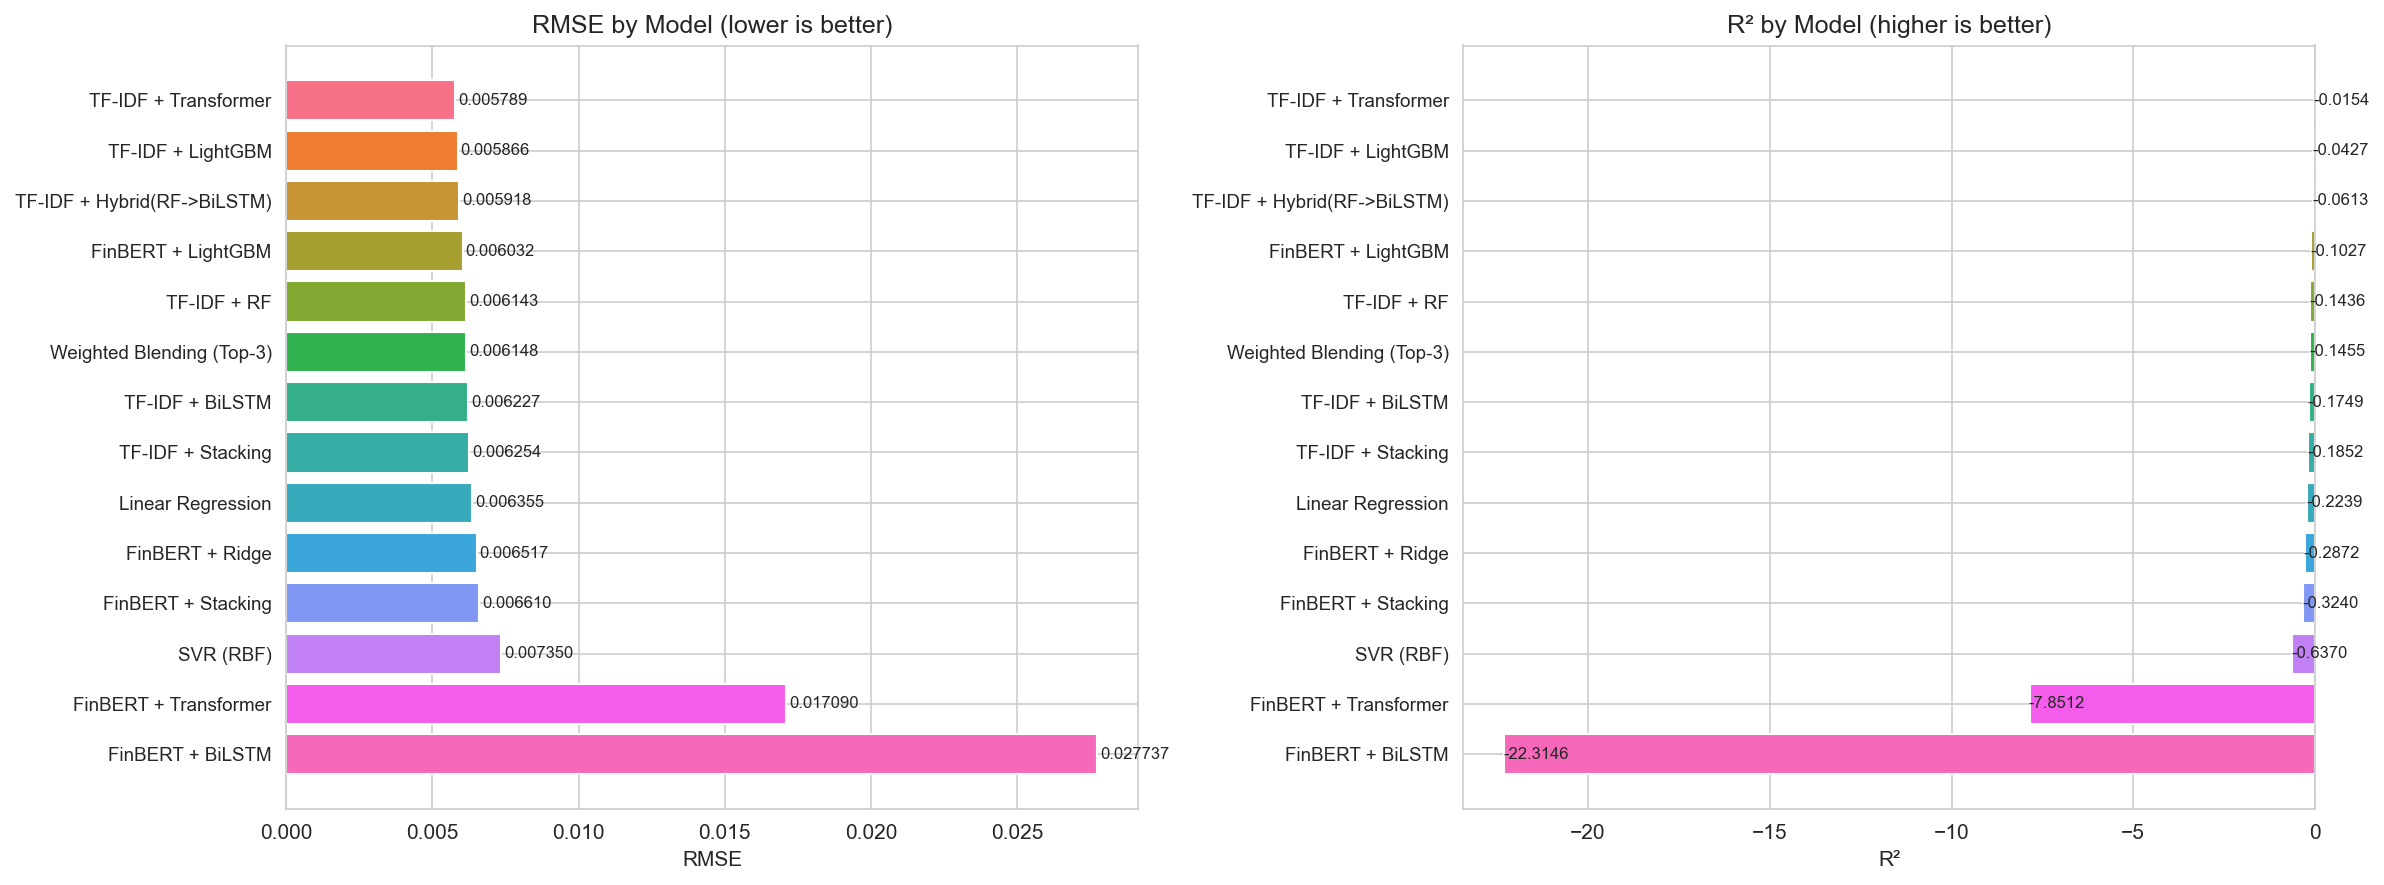

Saved: figures/fig1_performance_bars.png


In [25]:
# ============================================================
# FIGURE 1: Performance Bar Chart  (Grouped Bar: RMSE & MAE)
# ============================================================
# Exclude ablation-only models for main comparison
main_models = results_df[~results_df['Model'].str.contains('Fin Only|Naive')].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE bar
ax = axes[0]
colors = sns.color_palette("husl", len(main_models))
bars = ax.barh(range(len(main_models)), main_models['RMSE'].values, color=colors)
ax.set_yticks(range(len(main_models)))
ax.set_yticklabels(main_models['Model'].values, fontsize=9)
ax.set_xlabel('RMSE')
ax.set_title('RMSE by Model (lower is better)')
ax.invert_yaxis()
for i, v in enumerate(main_models['RMSE'].values):
    ax.text(v + 0.0001, i, f'{v:.6f}', va='center', fontsize=8)

# R² bar
ax = axes[1]
bars = ax.barh(range(len(main_models)), main_models['R2'].values, color=colors)
ax.set_yticks(range(len(main_models)))
ax.set_yticklabels(main_models['Model'].values, fontsize=9)
ax.set_xlabel('R²')
ax.set_title('R² by Model (higher is better)')
ax.invert_yaxis()
for i, v in enumerate(main_models['R2'].values):
    ax.text(v + 0.001 if v > 0 else v - 0.02, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig1_performance_bars.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig1_performance_bars.png")

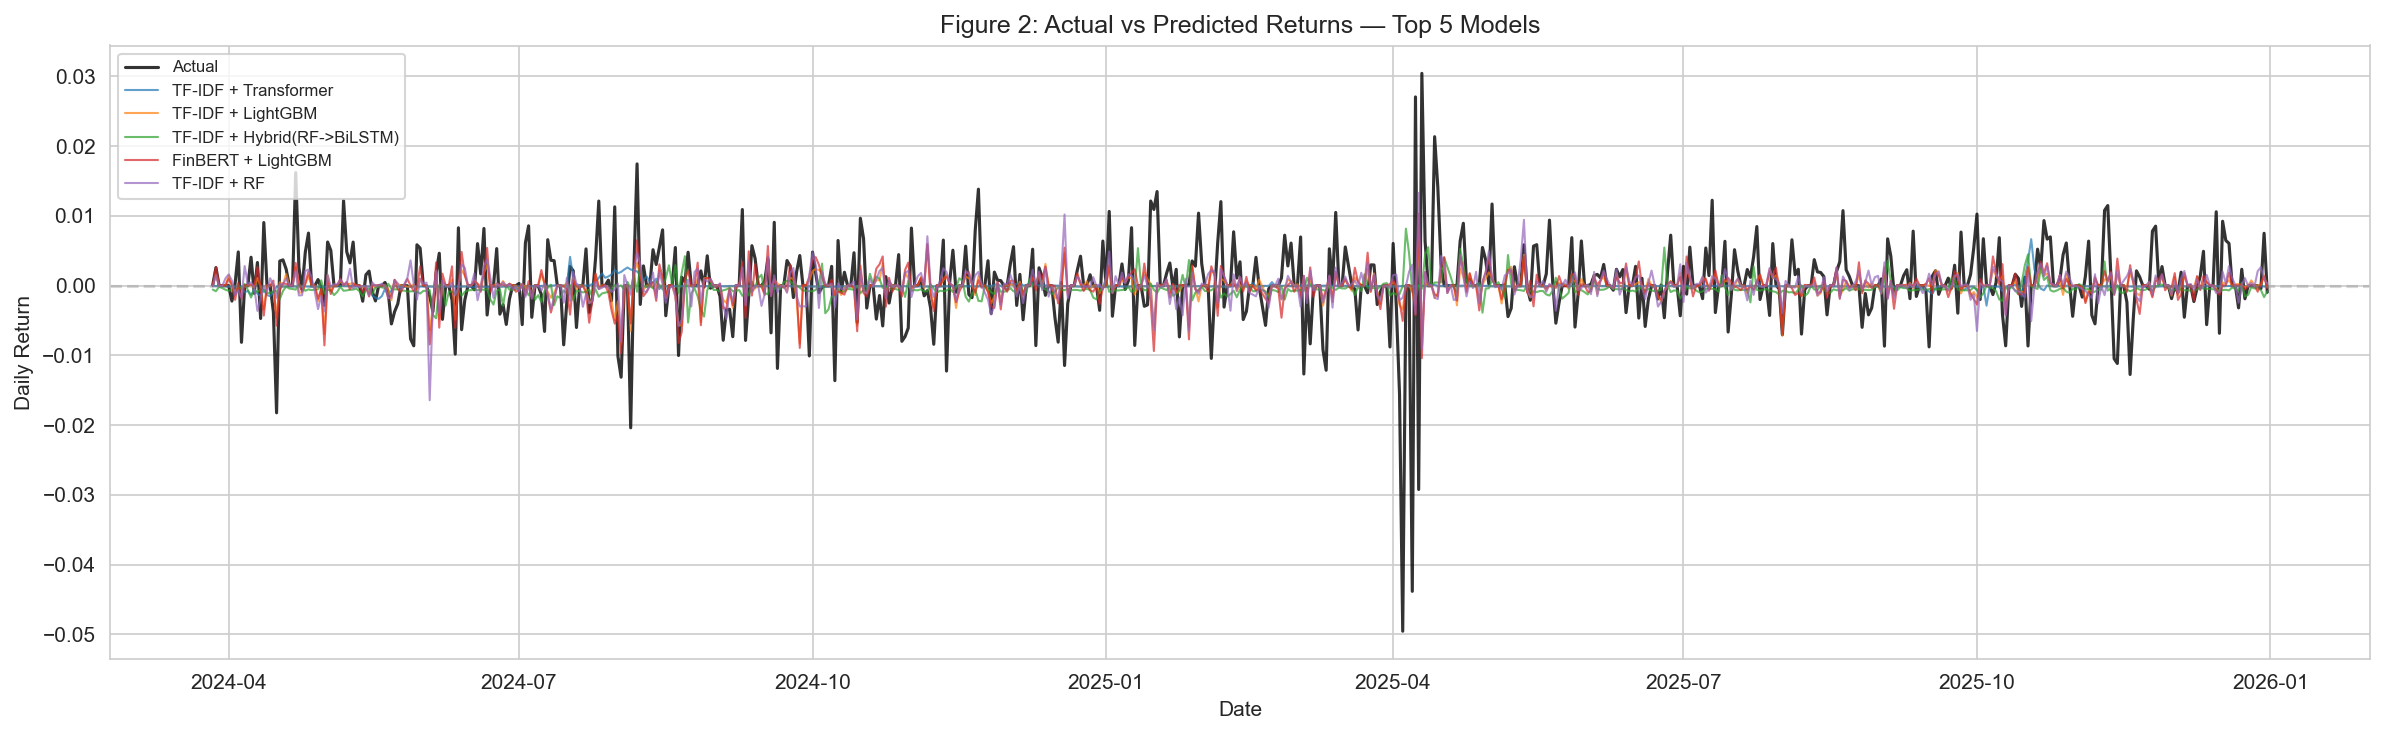

Saved: figures/fig2_actual_vs_predicted.png


In [26]:
# ============================================================
# FIGURE 2: Actual vs Predicted  (Top-5 Models on Test Set)
# ============================================================
top5 = results_df[~results_df['Model'].str.contains('Fin Only|Naive')].head(5)
top5_names = top5['Model'].tolist()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_dates[:n_test], y_test[:n_test], label='Actual', color='black',
        linewidth=1.5, alpha=0.8)

cmap = plt.cm.tab10
for idx, name in enumerate(top5_names):
    pred = predictions_dict[name][:n_test]
    ax.plot(test_dates[:n_test], pred, label=name, linewidth=1.0,
            alpha=0.7, color=cmap(idx))

ax.set_xlabel('Date')
ax.set_ylabel('Daily Return')
ax.set_title('Figure 2: Actual vs Predicted Returns — Top 5 Models')
ax.legend(fontsize=8, loc='upper left')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig2_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig2_actual_vs_predicted.png")

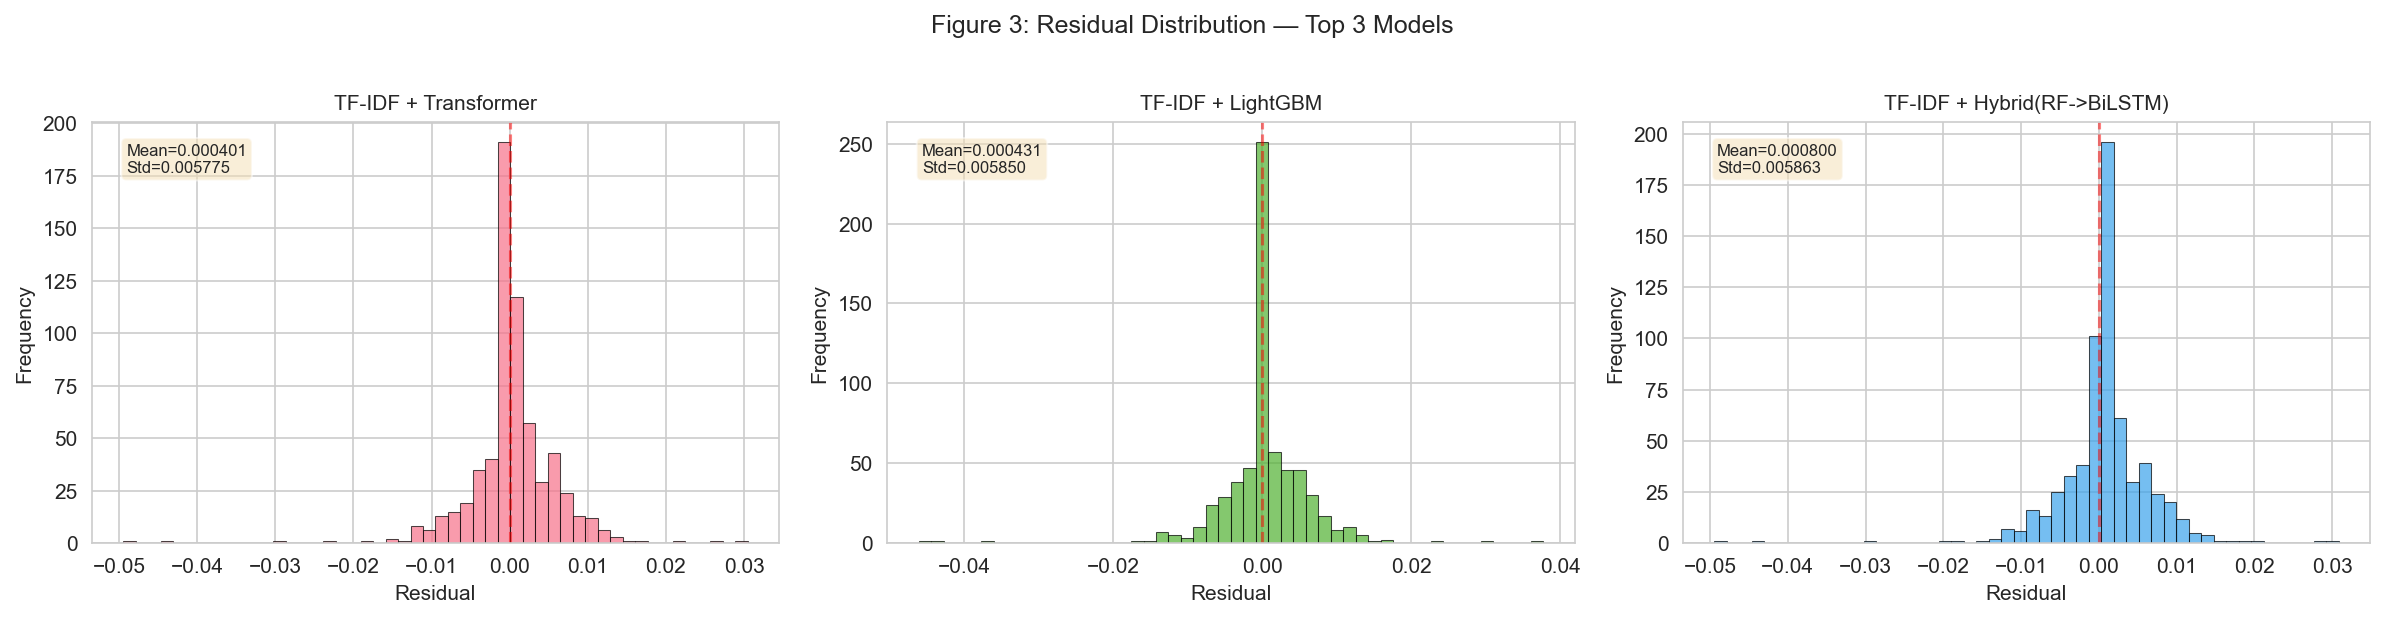

Saved: figures/fig3_residuals.png


In [27]:
# ============================================================
# FIGURE 3: Residual Distribution  (Top-3 Models)
# ============================================================
top3_names = results_df[~results_df['Model'].str.contains('Fin Only|Naive')].head(3)['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, name in enumerate(top3_names):
    pred = predictions_dict[name][:n_test]
    residuals = y_test[:n_test] - pred
    ax = axes[idx]
    ax.hist(residuals, bins=50, color=sns.color_palette("husl", 3)[idx],
            alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Frequency')
    m = np.mean(residuals)
    s = np.std(residuals)
    ax.text(0.05, 0.95, f'Mean={m:.6f}\nStd={s:.6f}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Figure 3: Residual Distribution — Top 3 Models', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig3_residuals.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig3_residuals.png")

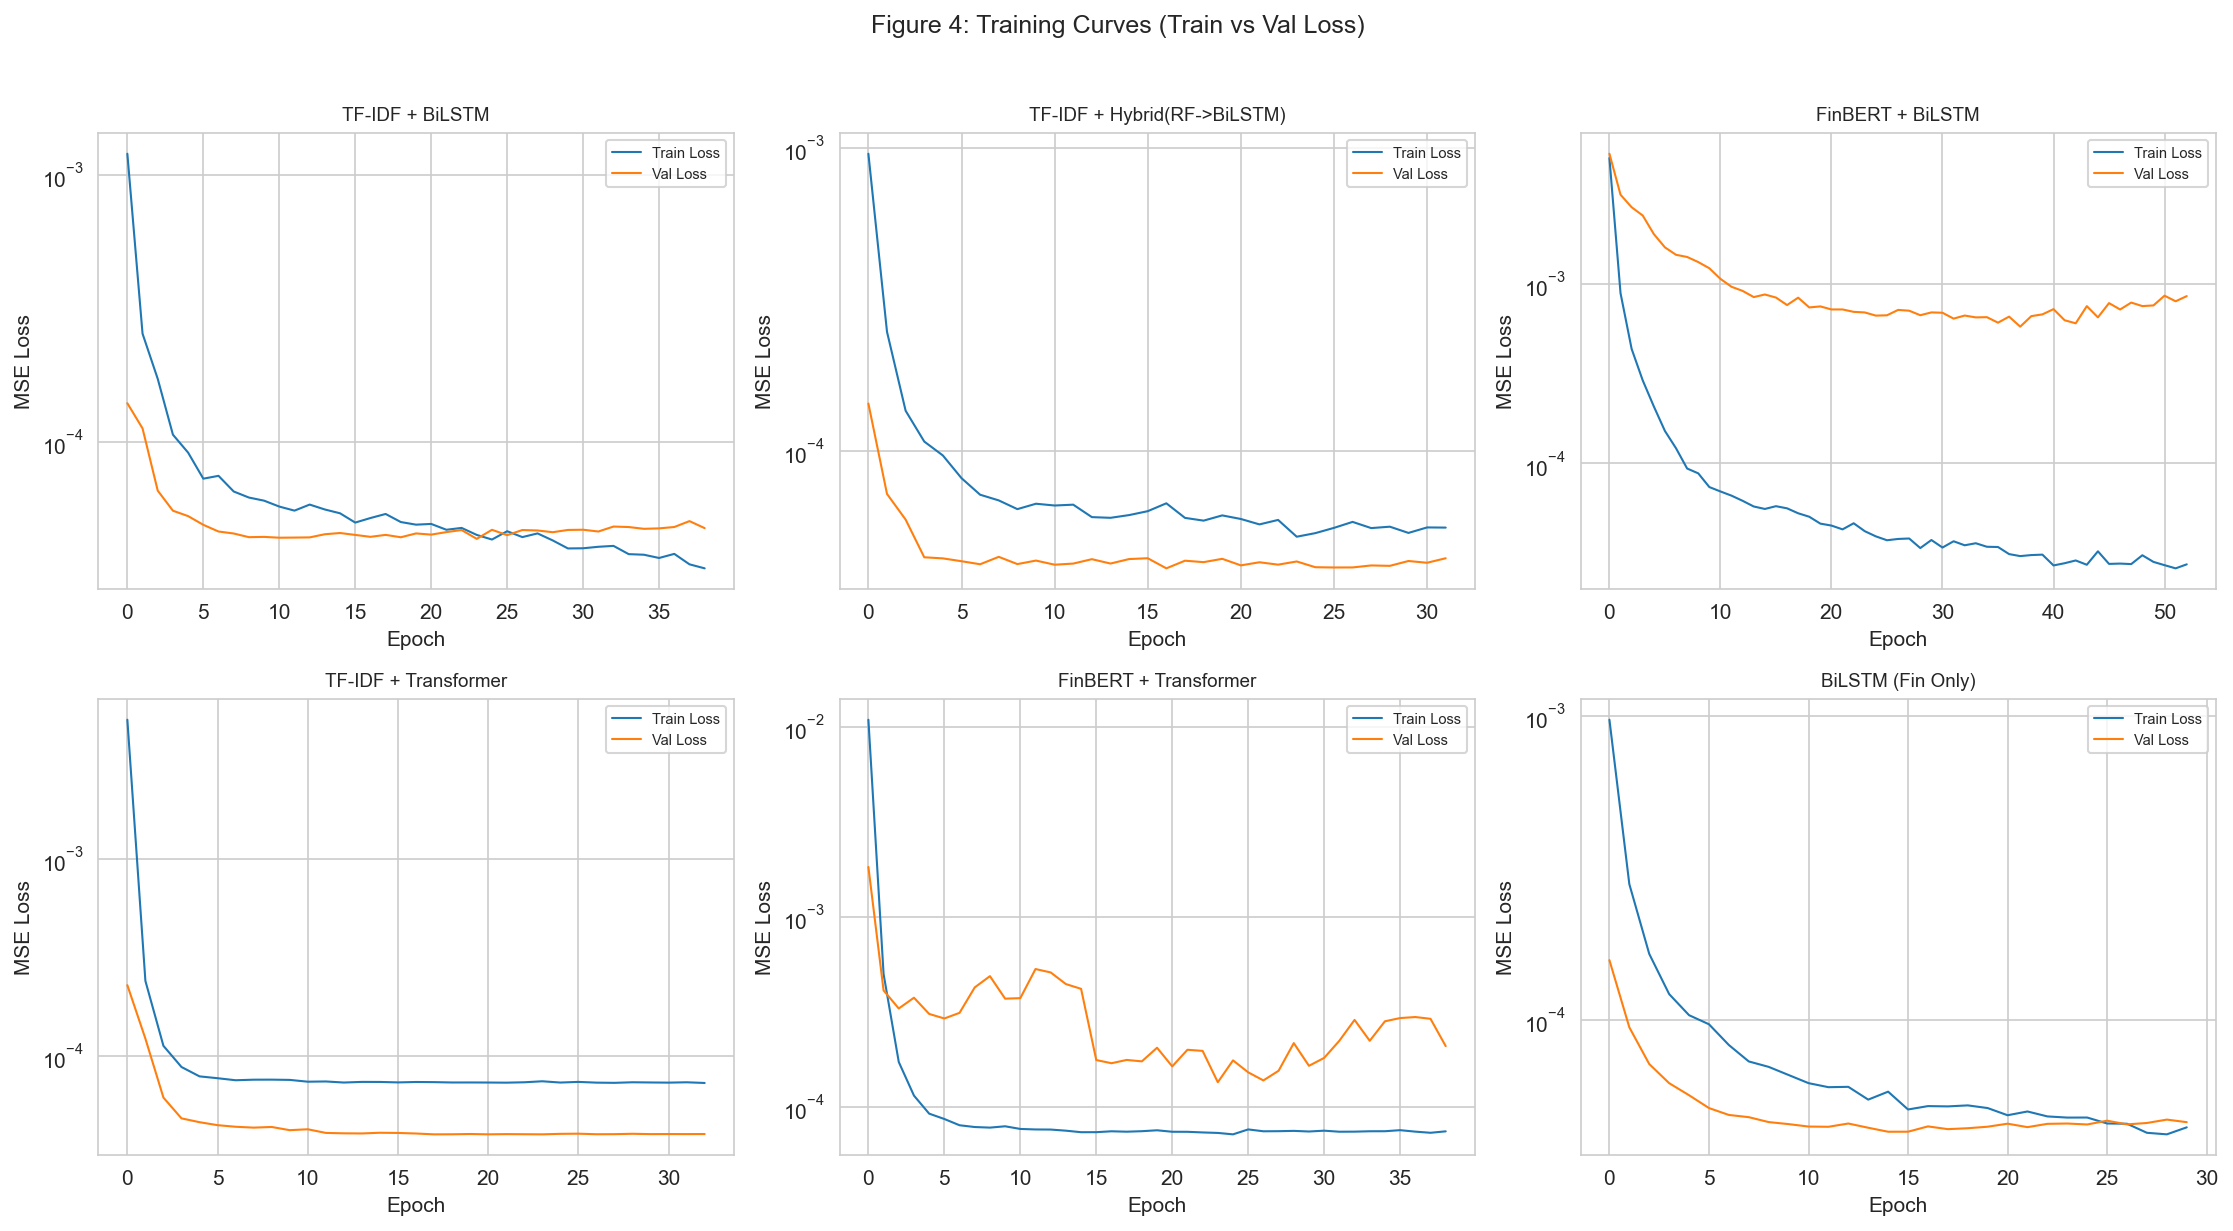

Saved: figures/fig4_training_curves.png


In [28]:
# ============================================================
# FIGURE 4: Training Curves  (Loss over Epochs)
# ============================================================
nn_models = [k for k in training_histories.keys()]
n_nn = len(nn_models)

if n_nn > 0:
    cols = min(3, n_nn)
    rows = (n_nn + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if n_nn == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for idx, name in enumerate(nn_models):
        ax = axes[idx]
        h = training_histories[name]
        ax.plot(h['loss'], label='Train Loss', linewidth=1)
        ax.plot(h['val_loss'], label='Val Loss', linewidth=1)
        ax.set_title(name, fontsize=9)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend(fontsize=7)
        ax.set_yscale('log')

    # Hide unused subplots
    for idx in range(n_nn, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Figure 4: Training Curves (Train vs Val Loss)', y=1.02)
    plt.tight_layout()
    plt.savefig('figures/fig4_training_curves.png', bbox_inches='tight')
    plt.show()
    print("Saved: figures/fig4_training_curves.png")
else:
    print("No neural network training histories to plot.")

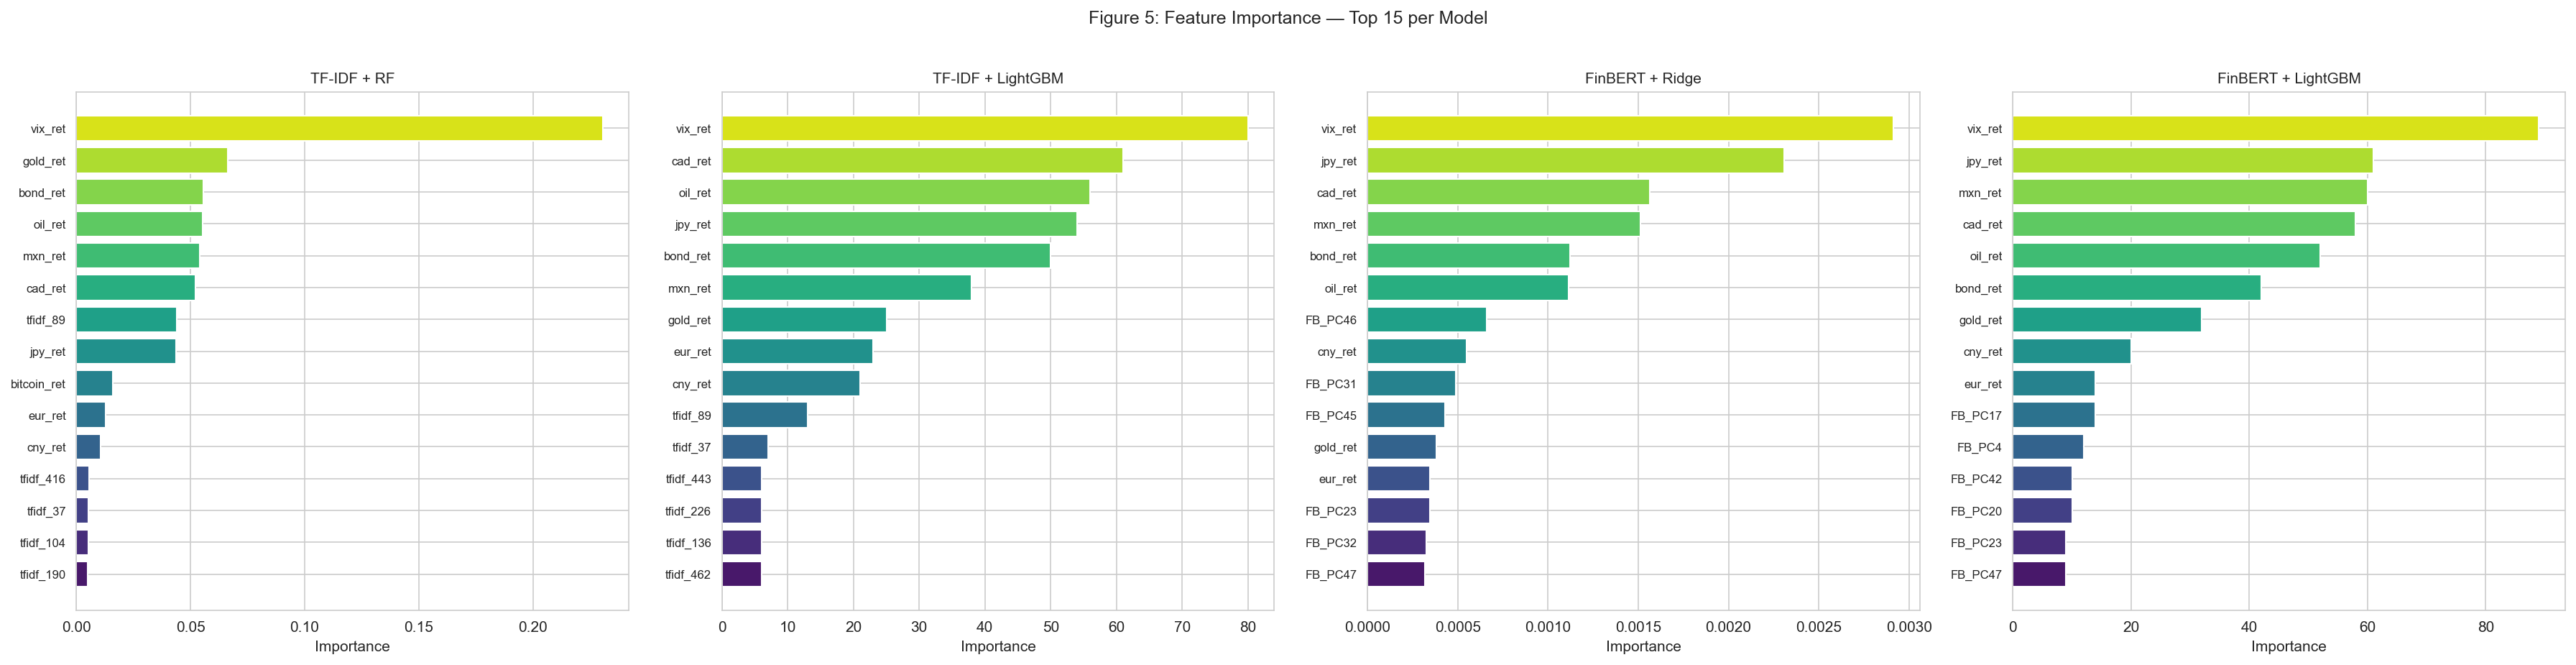

Saved: figures/fig5_feature_importance.png


In [29]:
# ============================================================
# FIGURE 5: Feature Importance  (Top Features per Model)
# ============================================================
fi_models = list(feature_importances_dict.keys())
n_fi = len(fi_models)

if n_fi > 0:
    fig, axes = plt.subplots(1, n_fi, figsize=(6 * n_fi, 6))
    if n_fi == 1:
        axes = [axes]

    for idx, name in enumerate(fi_models):
        ax = axes[idx]
        feat_names, feat_vals = feature_importances_dict[name]
        # Top 15
        top_idx = np.argsort(feat_vals)[-15:]
        top_names = [feat_names[i] for i in top_idx]
        top_vals  = feat_vals[top_idx]

        ax.barh(range(len(top_names)), top_vals,
                color=sns.color_palette("viridis", len(top_names)))
        ax.set_yticks(range(len(top_names)))
        ax.set_yticklabels(top_names, fontsize=8)
        ax.set_xlabel('Importance')
        ax.set_title(name, fontsize=10)

    plt.suptitle('Figure 5: Feature Importance — Top 15 per Model', y=1.02)
    plt.tight_layout()
    plt.savefig('figures/fig5_feature_importance.png', bbox_inches='tight')
    plt.show()
    print("Saved: figures/fig5_feature_importance.png")
else:
    print("No feature importance data.")

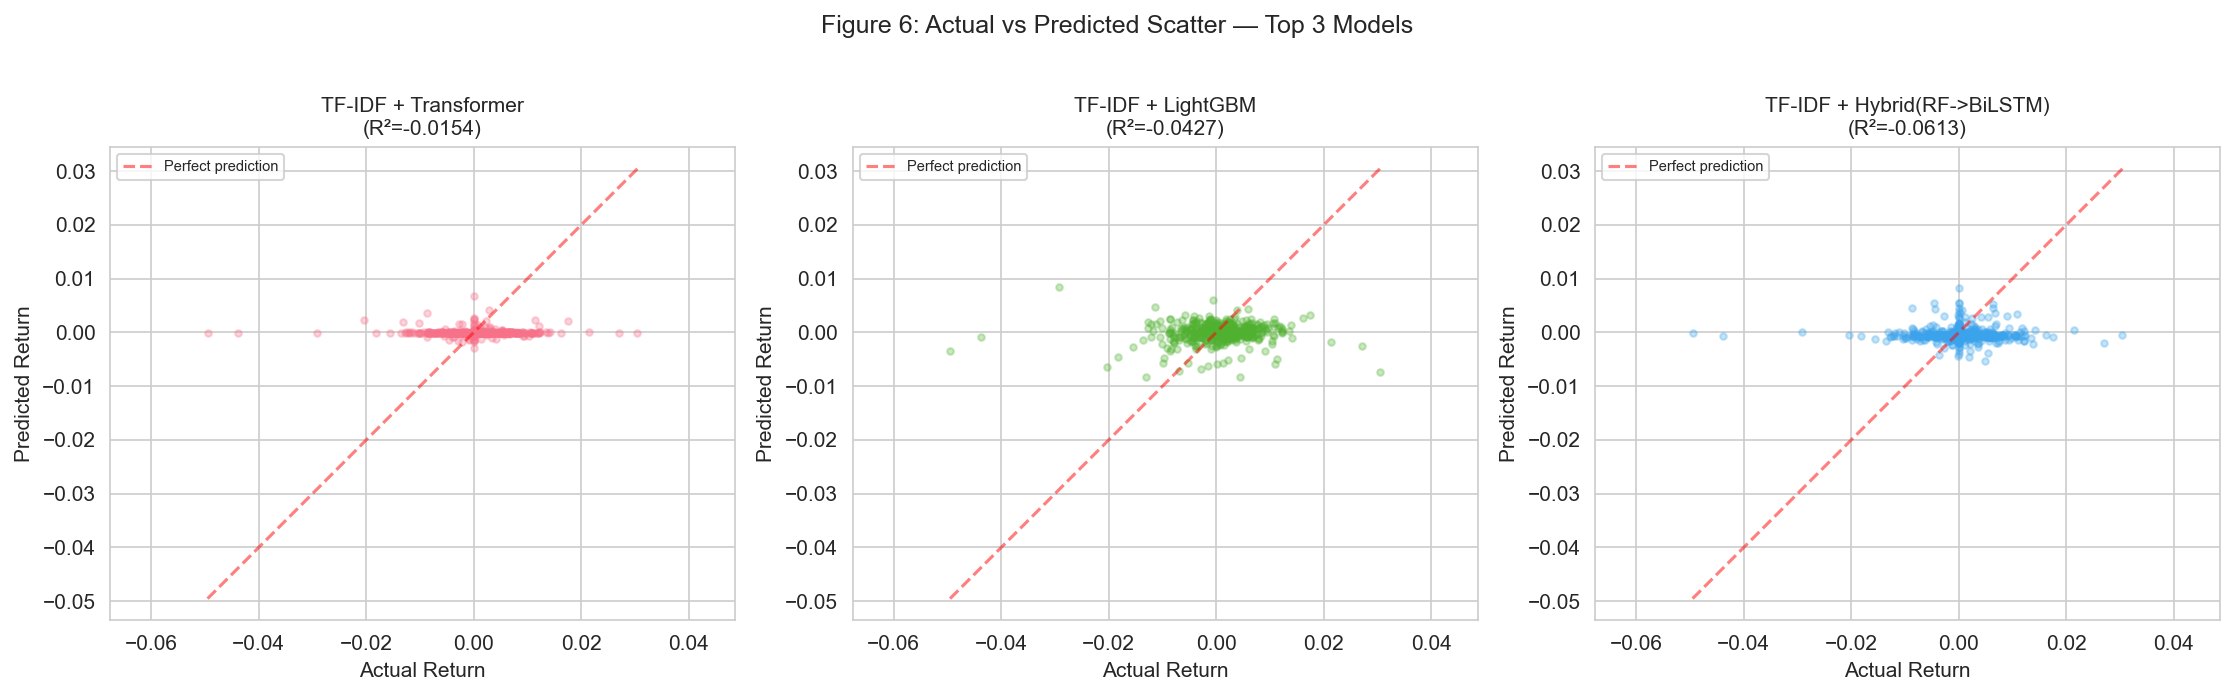

Saved: figures/fig6_scatter.png


In [30]:
# ============================================================
# FIGURE 6: Scatter Plot  (Actual vs Predicted, Top-3)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, name in enumerate(top3_names):
    ax = axes[idx]
    pred = predictions_dict[name][:n_test]
    actual = y_test[:n_test]

    ax.scatter(actual, pred, alpha=0.3, s=10,
               color=sns.color_palette("husl", 3)[idx])
    # 45-degree line
    lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect prediction')
    ax.set_xlabel('Actual Return')
    ax.set_ylabel('Predicted Return')
    ax.set_title(f'{name}\n(R²={r2_score(actual, pred):.4f})', fontsize=10)
    ax.legend(fontsize=7)
    ax.set_aspect('equal', adjustable='datalim')

plt.suptitle('Figure 6: Actual vs Predicted Scatter — Top 3 Models', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig6_scatter.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig6_scatter.png")

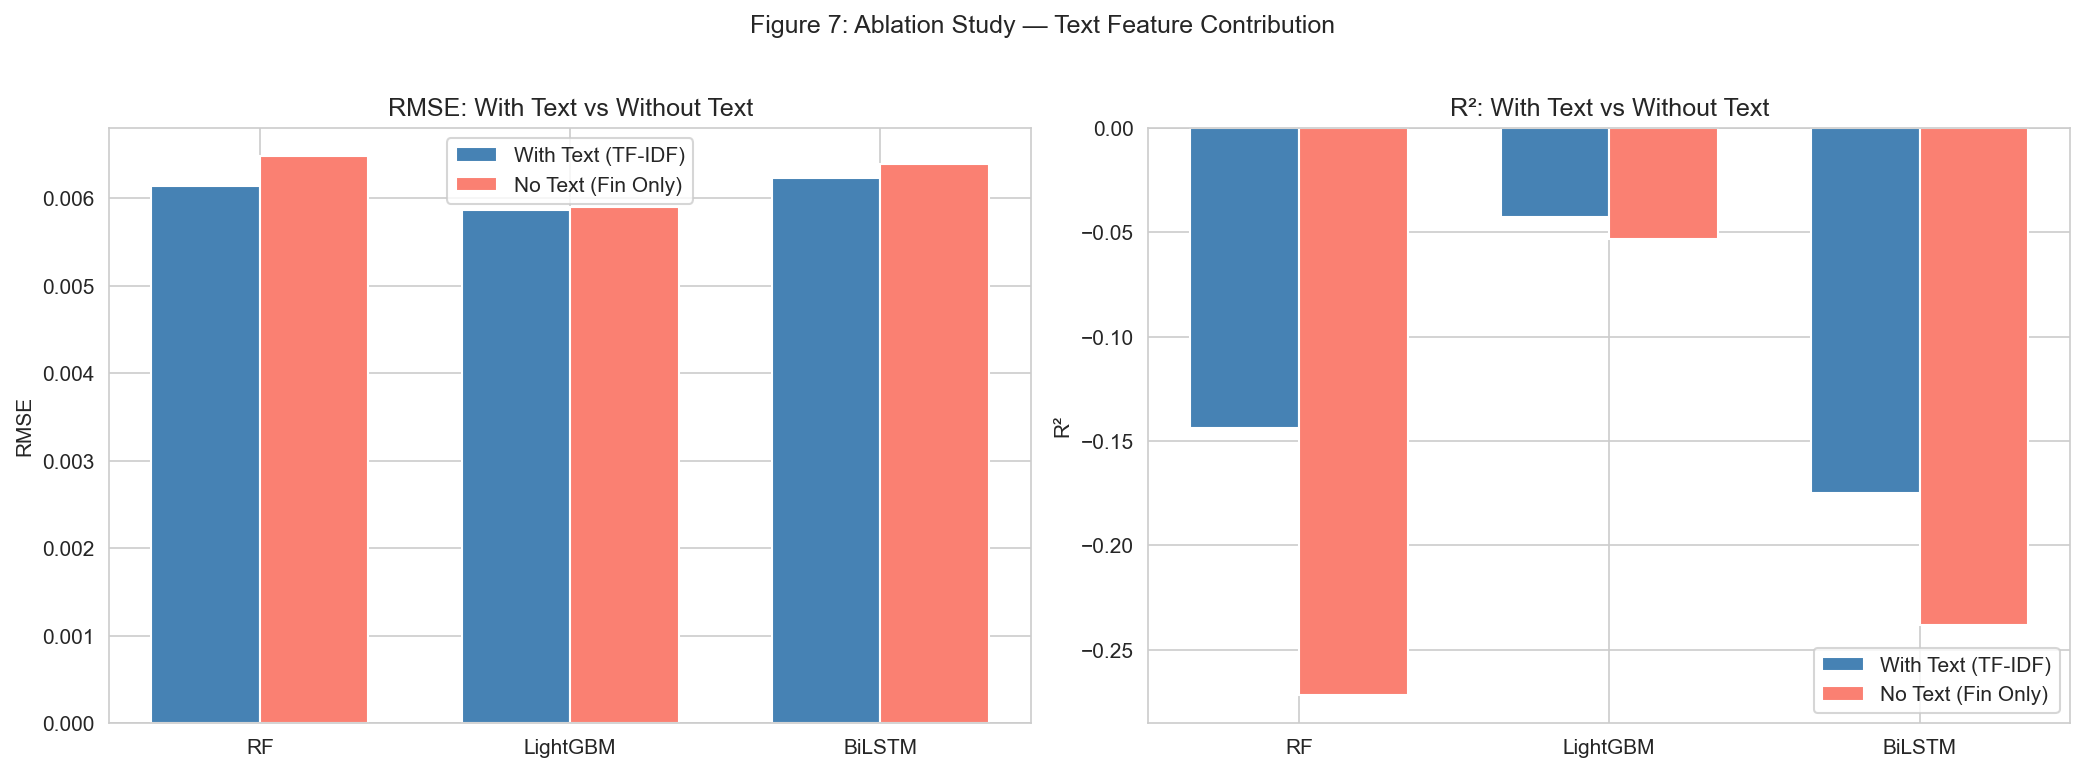

Saved: figures/fig7_ablation.png


In [31]:
# ============================================================
# FIGURE 7: Ablation Study Chart
# ============================================================
# Compare: with text vs without text for each algorithm
ablation_pairs = [
    ("RF",       "TF-IDF + RF",       "RF (Fin Only)"),
    ("LightGBM", "TF-IDF + LightGBM", "LightGBM (Fin Only)"),
    ("BiLSTM",   "TF-IDF + BiLSTM",   "BiLSTM (Fin Only)"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
ax = axes[0]
x = np.arange(len(ablation_pairs))
width = 0.35

rmse_with = []
rmse_without = []
labels = []
for label, with_name, without_name in ablation_pairs:
    r_with = results_df[results_df['Model'] == with_name]
    r_without = results_df[results_df['Model'] == without_name]
    if len(r_with) > 0 and len(r_without) > 0:
        rmse_with.append(r_with['RMSE'].values[0])
        rmse_without.append(r_without['RMSE'].values[0])
        labels.append(label)

x = np.arange(len(labels))
ax.bar(x - width/2, rmse_with, width, label='With Text (TF-IDF)', color='steelblue')
ax.bar(x + width/2, rmse_without, width, label='No Text (Fin Only)', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('RMSE')
ax.set_title('RMSE: With Text vs Without Text')
ax.legend()

# R² comparison
ax = axes[1]
r2_with = []
r2_without = []
for label, with_name, without_name in ablation_pairs:
    r_with = results_df[results_df['Model'] == with_name]
    r_without = results_df[results_df['Model'] == without_name]
    if len(r_with) > 0 and len(r_without) > 0:
        r2_with.append(r_with['R2'].values[0])
        r2_without.append(r_without['R2'].values[0])

ax.bar(x - width/2, r2_with, width, label='With Text (TF-IDF)', color='steelblue')
ax.bar(x + width/2, r2_without, width, label='No Text (Fin Only)', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('R²')
ax.set_title('R²: With Text vs Without Text')
ax.legend()

plt.suptitle('Figure 7: Ablation Study — Text Feature Contribution', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig7_ablation.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig7_ablation.png")

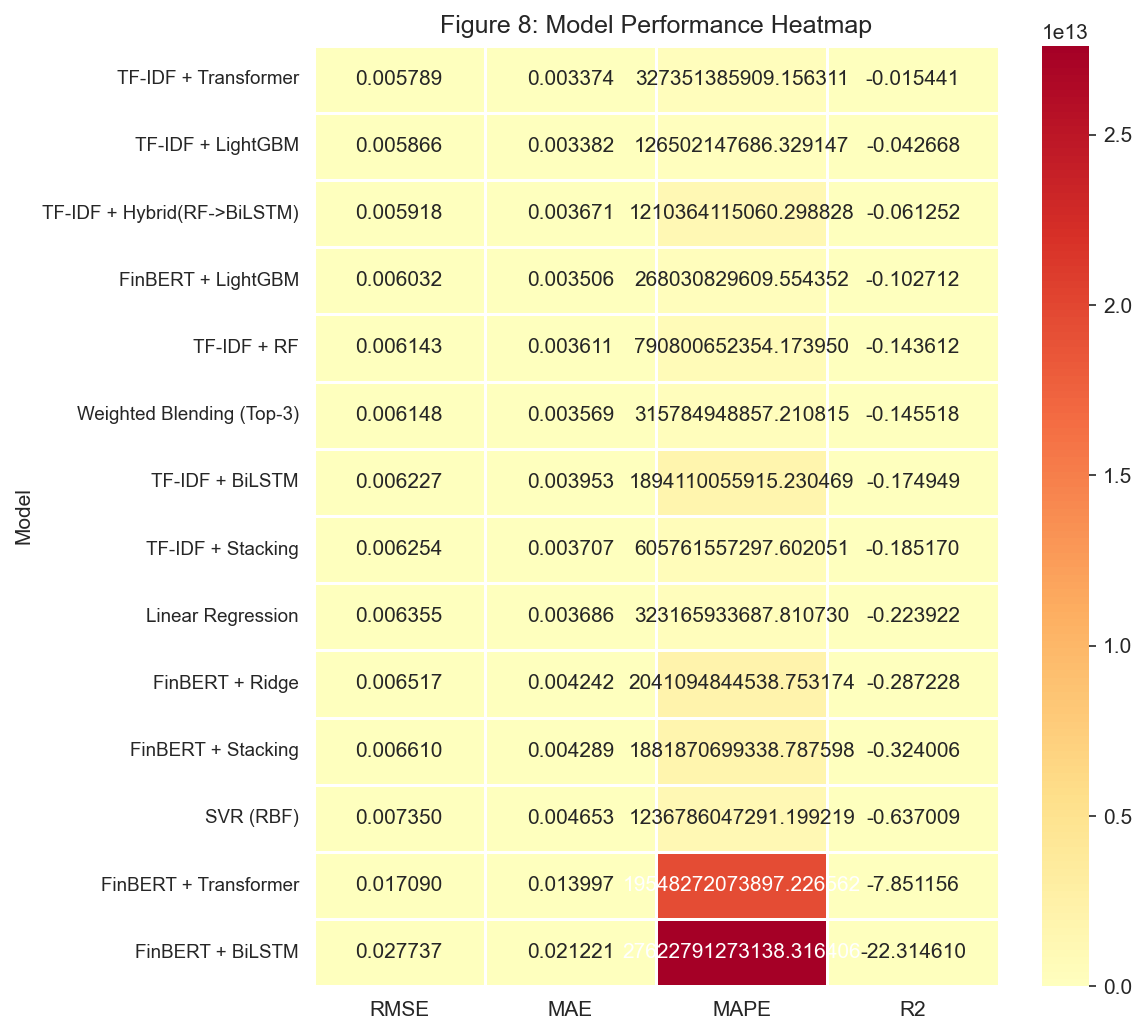

Saved: figures/fig8_heatmap.png


In [32]:
# ============================================================
# FIGURE 8: Performance Heatmap
# ============================================================
# Prepare heatmap data (main models only)
hm_df = results_df[~results_df['Model'].str.contains('Fin Only|Naive')].copy()
hm_data = hm_df.set_index('Model')[['RMSE', 'MAE', 'MAPE', 'R2']]

fig, ax = plt.subplots(figsize=(8, max(6, len(hm_data) * 0.5)))
sns.heatmap(hm_data.astype(float), annot=True, fmt='.6f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.5, center=hm_data['RMSE'].median())
ax.set_title('Figure 8: Model Performance Heatmap')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig8_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: figures/fig8_heatmap.png")

In [33]:
# ============================================================
# SAVE ALL RESULTS
# ============================================================
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

# Full results table
results_df_final = pd.DataFrame(results_list).sort_values('RMSE').reset_index(drop=True)
results_df_final.index = results_df_final.index + 1
results_df_final.to_csv('results/model_comparison.csv', index=True, index_label='Rank')

# Best model highlight
best = results_df_final.iloc[0]
print(f"\n*** BEST MODEL: {best['Model']} ***")
print(f"    RMSE = {best['RMSE']:.6f}")
print(f"    MAE  = {best['MAE']:.6f}")
print(f"    MAPE = {best['MAPE']:.4f}")
print(f"    R²   = {best['R2']:.4f}")

# Save predictions
pred_df = pd.DataFrame(predictions_dict)
pred_df.insert(0, 'Date', test_dates[:len(pred_df)])
pred_df.insert(1, 'Actual', y_test[:len(pred_df)])
pred_df.to_csv('results/all_predictions.csv', index=False)

print(f"\nFiles saved:")
print(f"  results/model_comparison.csv")
print(f"  results/all_predictions.csv")
print(f"  figures/fig1~fig8 (.png)")
print(f"\nTotal models evaluated: {len(results_df_final)}")
print("=" * 80)

# Display final table
results_df_final[['Model', 'Text_Rep', 'RMSE', 'MAE', 'MAPE', 'R2']]

FINAL SUMMARY

*** BEST MODEL: Naive (Mean) ***
    RMSE = 0.005753
    MAE  = 0.003321
    MAPE = 90096756323.9798
    R²   = -0.0029

Files saved:
  results/model_comparison.csv
  results/all_predictions.csv
  figures/fig1~fig8 (.png)

Total models evaluated: 18


,Model,Text_Rep,RMSE,MAE,MAPE,R2
1,Naive (Mean),None,0.005753,0.003321,9.009676e+10,-0.002928
2,TF-IDF + Transformer,TF-IDF,0.005789,0.003374,3.273514e+11,-0.015441
3,TF-IDF + LightGBM,TF-IDF,0.005866,0.003382,1.265021e+11,-0.042668
4,LightGBM (Fin Only),None,0.005896,0.003409,1.240901e+11,-0.053324
5,TF-IDF + Hybrid(RF->BiLSTM),TF-IDF,0.005918,0.003671,1.210364e+12,-0.061252
6,FinBERT + LightGBM,FinBERT,0.006032,0.003506,2.680308e+11,-0.102712
7,TF-IDF + RF,TF-IDF,0.006143,0.003611,7.908007e+11,-0.143612
8,Weighted Blending (Top-3),Mixed,0.006148,0.003569,3.157849e+11,-0.145518
9,TF-IDF + BiLSTM,TF-IDF,0.006227,0.003953,1.894110e+12,-0.174949
10,TF-IDF + Stacking,TF-IDF,0.006254,0.003707,6.057616e+11,-0.185170
